# PBL Submission 1: Machine Learning Fundamentals

#PBL1: Python Programming Environment for Machine Learning

### Overview
This section of the notebook is used to explore and analyse SARS-CoV-2 genetic mutation data to help understand the evolution of viral lineages. A machine learning model will be developed to predict viral lineages based on genetic mutations.

**Dataset:**

The SARS2EVO dataset contains:
- mutation data - mutations in genetics that have been identified in different viral samples
-  metadata - information about each sample, including classification of viral lineages



####Biological context:
- Viral lineages (e.g., Alpha, Beta, Delta, Omicron) are classified based on specific genetic mutations
- Mutations are represented as position and nucleotide changes (e.g., "22882T/G" means at position 22882, T changed to G)


####Learning objectives addressed:
- Load and preprocess biological data using pandas
- Explore and visualize genetic mutation patterns
- Transform multi-label mutation data into a format suitable for machine learning
- Train a simple classification model to predict viral lineage
- Interpret model results in a biological context

###Task 1 - loading and preprocessing data


####Setup
We import the following libraries for processing data, visualising data and machine learning tasks

- pandas for data loading, reading, manipulation and analysis
- matplotlib for data visualisation
- sklearn for multi-label binarisation and splitting into training and testing sets

In [1]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split

###Step 1:loading the data files:

- `pd.read_csv()` is used to read the TSV files

- column names are assigned to the data with no column headers



In [2]:
#load mutation data and metadata
df_mutation = pd.read_csv('sampled_sample_mutlist.tsv', sep='\t', names=['sample_ID_mutation'])
df_metadata = pd.read_csv('sampled_metadata.tsv', sep='\t', names=['sample_ID','Lineage','a','b'])

print(df_mutation.head())      # First few rows
print(df_mutation.info())      # Data types and structure
print(df_mutation.shape)       # Number of rows and columns


                                  sample_ID_mutation
0                           NMDC60013088-01:21656T/A
1                           NMDC60013090-01:24325A/G
2            GWHABKF00000001:3778A/G,8388A/G,8987T/A
3  GWHABKG00000001:104T/A,111T/C,112T/G,119C/G,12...
4                            GWHABKH00000001:6996T/C
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6763 entries, 0 to 6762
Data columns (total 1 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   sample_ID_mutation  6763 non-null   object
dtypes: object(1)
memory usage: 53.0+ KB
None
(6763, 1)


###Explanations, Results and Reflection

The file contains one single combined column. Each row represents a sample containing sampleID and a list of mutations (these 2 things are seperated by a colon).
Some samples have more than one mutation and each mutation is in the following format: [position][reference base]/[mutated base].


####Step 2: processing mutation data:
- currently the mutation file has combined sample_ID and mutations using a ':' to distinguish between them
- we use the python `.split()` funtion to seperate them
- once we do this we have 3 columns so must get rid of the original column as it shows redundant data using `df.drop()`


In [3]:
#split sample_ID and mutation data that is seperates by a ":"
df_mutation[['sample_ID', 'mutation']] = df_mutation['sample_ID_mutation'].str.split(':', expand=True)

#drop the original column (combined values)
df_mutation = df_mutation.drop(columns=['sample_ID_mutation'])

#remove duplicate sample_ids from mutation data
df_mutation = df_mutation[~df_mutation['sample_ID'].duplicated()]

###Explanations, Results and Reflection

Data may be stored in combined format initially as it is more compact and therefore would take up less storage space. This may also be the format in which it is retrieved from the technology used.

If a sample has no mutations it may have a NaN value in its mutations column after being split. These should be handled by keeping them as these samples are just mutation free.



####Step 3: handling missing metadata values

- `df.isnull().sum()` is used to check the metadata for values equal to null and then returns the count of how many null values exist
- df['column'].fillna() is used to replace these values with an 'unknown' value




In [ ]:

#remove duplicate samples from metadata
df_metadata = df_metadata[~df_metadata['sample_ID'].duplicated()]

#count missing values per column
df_metadata.isnull().sum()

#replace empty value with 'unknown'
df_metadata['Lineage'].fillna('unknown', inplace=True)

#drop the unused columns
df_metadata = df_metadata.drop(columns=['a', 'b'])


###Explanations, Results and Reflection
A missing lineage in a biological context may mean the lineage is undiscovered/unknown. Removing these would be a mistake as there is a possibility that all these belong to the same lineage, but even if they were individually different lineages, they provide important information about mutations. It is better to label them as unknown as these help in analysis.


####Step 4: merging datasets
- merge mutation data and metadata on the sample_ID key using `pd.merge`
- convert mutations column so that each mutation is its own sepeate item in a list


In [5]:
#the mutation and metadata is merged on the column they share
merged = pd.merge(df_mutation, df_metadata, on='sample_ID')

#list is created by splitting values in the string on a ':'
merged['mutation'] = merged['mutation'].str.split(',')



###Explanations, Results and Reflection

If sample_id exists in one dataset but not the other, only the rows with sample_id present in both remains otherwise the row is removed from merged.

After merging there are 6753 samples. This is expected if both datasets have the same amount of unique samples and none are lost during merging. It suggests both set of data were created at the same time.

In [6]:
#first few rows of merged dataset
print(merged.head())

         sample_ID                                          mutation Lineage
0  NMDC60013088-01                                        [21656T/A]       B
1  NMDC60013090-01                                        [24325A/G]       B
2  GWHABKF00000001                       [3778A/G, 8388A/G, 8987T/A]       B
3  GWHABKG00000001  [104T/A, 111T/C, 112T/G, 119C/G, 120T/C, 124G/A]       B
4  GWHABKH00000001                                         [6996T/C]       B


Task 1 Observations:

The final merged dataset shows a row for each distinct viral sample - 6753 samples.
Each sample has an ID value, a list of genetic mutations and a viral lineage.

The data quality issue met was a sample  which did not contain data informing on it's lineage. This issue was resolved by replacing empty values with 'unknown'.
There were also duplicate sample_IDs in the metadata so these were removed.
Data was originally also stored as single strings and was converted into lists of strings.


In [7]:
print(merged)

             sample_ID                                           mutation  \
0      NMDC60013088-01                                         [21656T/A]   
1      NMDC60013090-01                                         [24325A/G]   
2      GWHABKF00000001                        [3778A/G, 8388A/G, 8987T/A]   
3      GWHABKG00000001   [104T/A, 111T/C, 112T/G, 119C/G, 120T/C, 124G/A]   
4      GWHABKH00000001                                          [6996T/C]   
...                ...                                                ...   
6748  EPI_ISL_15136801  [241C/T, 577T/A, 670T/G, 1931C/A, 2216T/C, 279...   
6749  EPI_ISL_15137775  [241C/T, 670T/G, 1627C/T, 2790C/T, 3037C/T, 41...   
6750  EPI_ISL_15138711  [241C/T, 670T/G, 1627C/T, 2790C/T, 3037C/T, 41...   
6751  EPI_ISL_15140196  [44C/T, 241C/T, 670T/G, 1627C/T, 2790C/T, 3037...   
6752  EPI_ISL_15144373  [241C/T, 670T/G, 1627C/T, 1912C/T, 2790C/T, 30...   

       Lineage  
0            B  
1            B  
2            B  
3      

###Task 2 - Exploring and visualising the data


####Step 1: analysing lineage distribution


*   `value_counts()` function used to count number of samples in each lineage, and then to identify modal lineages
* bar chart created using matplotlib to visualise our findings
  
  arrays for axis:

  .index for lineage names

  .values for counts in the sample






In [8]:
#counting number of values under each lineage type
lineage_counts = merged['Lineage'].value_counts()

#storing the 10 most common lineages
top_lineages = lineage_counts.head(10)

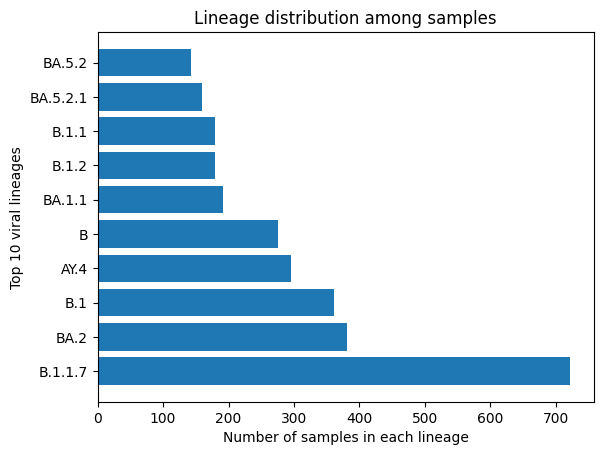

In [9]:
#creating a bar chart to display distibution of top 10 lineages in samples
#horizontal bar chart
plt.barh(top_lineages.index, top_lineages.values)

#titles and labels of bar chart
plt.title('Lineage distribution among samples')
plt.xlabel('Number of samples in each lineage')
plt.ylabel('Top 10 viral lineages')

#displaying chart
plt.show()


###Explanations, Results and Reflection
The most represented lineages in the dataset are B.1.1.7, BA.2 add B.1. This is because they are present in the majority of samples in the dataset, probably due to being more tranferrable or due to outbreaks.

There are many lineages with much fewer samples. The causes patterns that are difficult for machine learning due to such few cases as well as imbalance.

In a real-world public health context, an imbalanced dataset could cause bias in prediction towards the more common samples. Rare lineages may not be payed attention to even if they are just as strong or dangerous as others. This could cause less accurate outbreak serveillence.

####Step 2: filtering data for analysis
* filter data for top 3 lineages to make classification more focussed

In [10]:
#create a list of the top 3 lineages from index
top_3_list = top_lineages.index[0:3].tolist()

# filter to top 3 most common lineages
filtered = merged[merged['Lineage'].isin(top_3_list)]

###Explanations, Results and Reflection
One reason we focus on common lineages because they have many samples. Rarer lineages may not contain enough samples for a model to learn important patterns.

The main trade off to only using 3 lineages over all of them is the model not being completely biologically complete - not being able to generalise to lineages outside of the top 3 in the sample due to overfitting. But training is simpler and classes are balanced.



####Step 3: analysing mutation patterns


* `exploded = df['list_column'].explode()`  used to seperate a column with lists into seperate rows
*   exploded values then counted and ranked



In [11]:
#seperate list values into seperate rows for each mutation
exploded = filtered['mutation'].explode()

#count occurances of each mutation
mutation_counts = exploded.value_counts()

#rank top 10% of mutations
specific_range = mutation_counts.index[90:100]
specific_values = mutation_counts.values[90:100]

###Explanations, Results and Reflection

Some mutations may be more common than others because they are present in the most dominant lineages. These mutations would have allowed the virus to have an advantage and survive and spread over time, building up the amount of the particular muatations in lineages. This in turn causes them to appear in many samples.

Mutation frequency may indicate its transmission ability: higher frequency = higher transmission and better adaptations to environments.




Task 2 observations:

Using the visualisation of top 10 lineages among the samples we can see that the lineages are not distributed evenly, with some lineages having more than 4 times the samples and others.

Because of this, the top 3 most common lineages were selected, as they make up for a large portion of the dataset. This ensures that classes will have enough data to learn from and rare lineages' impact on results is reduced.

Observing the mutation data, it can be seen that a few mutations occur frequently but most mutations usually only appear in fewer samples.

This observation may cause challenges as if we used rare mutations for training, it may cause overfitting meaning it may be too specific to these rare occurances and wrongly predict mutations as these. Also, using all lineages would produce bias towards the more common lineages.



###Task 3 - Preparing data for machine learning

####Step 1: Creating a binary feature matrix.
This is needed as we have multi label data (samples may have more than one mutation)


In [12]:
mlb = MultiLabelBinarizer()

#multi-label binarisation to transform mutation list
X = mlb.fit_transform(filtered['mutation'])
feature_names = mlb.classes_

In [13]:
#creating dataframe from matrix
X_df = pd.DataFrame(X, columns=feature_names, index=filtered.index)

In [14]:
print("Number of mutations:", X_df.shape[1])
print("Number of samples:", X_df.shape[0])

Number of mutations: 4196
Number of samples: 1464


###Explanations, Results and Reflection
The mutations must be converted into binary format as this is what is required by machine learning algorithms.

In the binary matrix
- 1 = mutation present in a sample
- 0 = mutation NOT present in a sample

Overall there are 4196 mutation features across much fewer samples so overfitting may occur.

####Step 2: selecting relevant features
using `mutation_counts`


In [15]:
#[90:100] would mean mutations between the 90th to 100th most common
selected_mutations = mutation_counts.index[90:100]

#create a dataframe for these
X_selected = X_df[selected_mutations]

###Explanations, Results and Reflection
Common mutations may want to be excluded as they wont help distinguish lineages if they are in most lineages to begin with.

Rare mutations might want to be excluded as they may cause overfitting, making the model unstable as it fixates on small characteristics.

####Step 3: preparing target variable


*   extract lineage information as target variable using `y = df['column_X']`
*   verify features and target have same number of samples



In [16]:
#extracting lineage as target to predict
y = filtered['Lineage']

#making sure number of samples are equal
print(f"Features shape: {X_selected.shape}")
print(f"Target shape: {y.shape}")

Features shape: (1464, 10)
Target shape: (1464,)


####Step 4:

splitting data into training and testing sets



*   `test_size=X` used to split the data so that X percent is part of the testing set and the remaining is training
*   a fixed random state is used to make sure the same split is used every time the code is run, making it reproduceable



In [17]:
#training and testing split
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

###Explanations, Results and Reflection

It is important to split data before training so that a model can learn patterns and be evaluated on data it has not seen previously. The test set acts similarly to what real data would look to a model.

If the model was evaluated and trained on the same data, overfitting bias would occur as the model may memorise specific traits that arent relevent and then when exposed to new data, will perform much worse.

We must set the random state as it ensures reproducibility - same samples used for each test every time code is run. If this number is changed it doesnt matter for the model it just gives different sets for the split and so performance may vary slightly.

####Step 5: verifying prepared data
* testing features, targets
* check class distribution



In [18]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1171, 10)
X_test shape: (293, 10)
y_train shape: (1171,)
y_test shape: (293,)


Features:
* 1171+293 = 1464 samples in total
* 10 features for the selected 10 mutations
* 293 = 20% of 1464

Targets:
* one label per sample
* target sizes match feature sizes

In [19]:
# displaying a sample of training features
print(X_train.head())

      22882T/G  28095A/T  29733CGAGGCCACGCGGAGTACGATCGAGTG/C  25563G/T  \
5663         1         0                                   0         0   
3153         0         1                                   0         0   
1209         0         0                                   0         1   
3839         0         1                                   0         0   
5438         1         0                                   1         0   

      17615A/G  1059C/T  15096T/C  22792C/T  2110C/T  14120C/T  
5663         0        0         0         1        0         0  
3153         0        0         0         0        1         1  
1209         0        1         0         0        0         0  
3839         0        0         0         0        1         1  
5438         0        0         0         0        0         0  


In [20]:
print("Training lineage distribution:")
print(y_train.value_counts())

print("\nTesting lineage distribution:")
print(y_test.value_counts())


Training lineage distribution:
Lineage
B.1.1.7    574
BA.2       304
B.1        293
Name: count, dtype: int64

Testing lineage distribution:
Lineage
B.1.1.7    148
BA.2        77
B.1         68
Name: count, dtype: int64


Training distribution:


*   574/1171 = 49%
* 304/1171 = 26%
* 293/1171 = 25%

Testing distribution:
* 141/293 = 50%
* 77/293 = 26%
* 68/292 = 23%




Task 3 observations:

The final number of features selected is 10, as we chose 10 mutations with frequencies that wont cause any bias in classififcation.

The training set contains 1171 samples and the testing set contains 293 samples due to the test set size of 20% chosen.

The lineage distribution is similar in both sets.


###Task 4 - Training and evaluating a classification model

####Step 1: training a decision tree classifier


*   decision tree classifier initialised
*   maximum depth set to prevent overfitting
*   model trained on training data
*   max depth of 2 prevents overfitting





In [21]:
#import decision tree classifier for classification
from sklearn.tree import DecisionTreeClassifier

#initialise a simple decision tree model with a smaller max depth and fixed random state
clf = DecisionTreeClassifier(max_depth=2, random_state=42)

#train tree using training data
clf.fit(X_train, y_train)



DecisionTreeClassifier(max_depth=2, random_state=42)

###Explanations, Results and Reflection

max_depth controls the max number of splits from root to leaf in the decision tree
- if too high, overfitting may occur where lineage patterns arent actually learned
- if too low, underfitting may occur and relationships may be missed

A shallow tree may be better for this data as it would improve generalisation of the model.



####Step 2: making predictions and evaluating


*   trained model evaluated using test set to estimate performance



In [22]:
#import metrics to evaluate model
from sklearn.metrics import accuracy_score

#use test set to test model's predicted lineages
y_pred = clf.predict(X_test)

#calculate accuracy of model to 2 dp
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.89


###Explanations, Results and Reflection
Accuracy of 0.85 means that the model was able to successfuly classify 85% of samples. This is high but it is important to consider the 15% of misclassifications.

In a public health context:
- correct lineage classification means there is good tracking of variants of the virus, allowing for specific actions to be taken like precautions but also for changes to vaccines.
- misclassification means delayed detection of new variants and delayed reactions/precautions/steps taken for public safety.

I would not trust this model for real world use as is it based on a small dataset that only has 10 features and 3 lineages. After more data is sampled with more features, this should also be evaluated on a dataset outside of the original.

####Step 3: Analyse feature importance


*   Extract most important mutations for model predictions using `classifier.feature_importances_` - each importance score value represents how much that feature effects the reduction of classification error
*   visualise most important mutations



In [23]:
#calculate importance scores
importances = clf.feature_importances_

#create a DataFrame to organize scores with mutations - sort in descending order
importance_df = pd.DataFrame({
    'Feature': X_selected.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False)

In [24]:
#display top 10 mutations
importance_df.head(10)

,Feature,Importance
0,22882T/G,0.660193
3,25563G/T,0.339807
1,28095A/T,0.000000
2,29733CGAGGCCACGCGGAGTACGATCGAGTG/C,0.000000
4,17615A/G,0.000000
5,1059C/T,0.000000
6,15096T/C,0.000000
7,22792C/T,0.000000
8,2110C/T,0.000000
9,14120C/T,0.000000


###Explanations, Results and Reflection
The mutations that are most predictive of lineage are features that have high importance scores in the decision tree as they allow for discrimination. This makes sense because lineages have very specific changes in their evolution that would allow discrimination like adaptations.

This is useful information for:
- vaccine development as antigens may be affected by specific mutations and so updates to vaccines can occur.
- public health surveillence as detection of lineages can occur and isolation or precautions can happen to prevent spread. Also symptoms can be studied.
- understanding viral evolution due to survival adaptations by mutations.

####Step 4: Reflecting on model

Overall, accuracy of the decision tree was 0.89 which means 89% of test samples were able to be classified correctly by the model. This supports that certain mutations are associated more with certain lineages, however it is important to consider that only the top 3 lineages were used and a shallow depth of tree was used so may not reflect the real world with many more lineages with high accuracy.


It is shown that classification of lineages can be determined from 2 mutation features, suggesting that a small number of specific mutations have a high association with specific lineages.

One limitation of the approach used is that only three lineages and 10 mutations are used. This means not all genetic differences may be accounted, for example rare mutations may be missed by the model. Additionally, the tree only had a depth of 2 so more complex relationships between mutations cant be modelled.

Something that could be donw differently would be to include a larger number of mutations in training so that more rare mutations could be predicted. Experimenting with increasing the maximum depth of the decision tree a little could also be used.

In a real world setting, more mutations and lineages should be used, as well as a larger maximum depth.



#PBL2: Supervised Learning Algorithms



### Overview
This section explores heart disease risk in patients to help clinicians prioritise interventions for high risk individuals. Heart disease is the leading cause of death worldwide

**Dataset**
The dataset used is the UCI heart disease dataset containing anonymised patient records for numerous hospitals.

Each record includes:
- **Demographics**: Age, sex
- **Clinical measurements**: Resting blood pressure, cholesterol, fasting blood sugar, maximum heart rate achieved
- **Symptoms and diagnoses**: Chest pain type, exercise-induced angina, ST depression induced by exercise relative to rest
- **Disease severity**: A column (e.g. num) with values 0, 1, 2, 3, 4 (0 = no disease, 1–4 = disease present at varying severity).


####Clinical context:
-  Early detection reduces mortality
- over-diagnosis can lead to unecessary anxiety and procedures.

####learning objectives
- Preprocess clinical data (missing values, abnormal values, categorical encoding, scaling)
- Split data and perform feature selection without label leakage
- Train and compare supervised classifiers (e.g. Logistic Regression, Random Forest, SVM, KNN)
- Evaluate models with accuracy, precision, recall, F1-score and confusion matrices
- Interpret results in a clinical context


##Task 1: Data Preprocessing

###Step 1 - Loading and Inspecting the Dataset

- Load dataset from CSV file
- Inspect structure
- Check for missing values in columns
- Summarise numerical columns

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

In [26]:
df_heart=pd.read_csv('heart_disease_uci.csv')

print("First few rows:")
print(df_heart.head())

print("\nMissing values:")
print(df_heart.isnull().sum())

print("\nSummary statistics for numerical columns:")
print(df_heart.describe())

First few rows:
   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0  
4             normal

###Explanations, Results and Reflection
The dataset contains: 920 rows (patients) and 16 columns (features).

These columns are numerical:
- id
- age
- trestbps
- chol
- thalch
- oldpeak
- ca
- num (target)

These columns are categorical:
- sex
- dataset
- cp
- restecg
- slope
- thal

The number of missing values are as shown:
- trestbps	59
- chol	30
- fbs	90
- restecg	2
- thalch	55
- exang	55
- oldpeak	62
- slope	309
- ca	611
- thal	486

All other columns have no missing values.

For clinical data, some measurements may be missing due to different hospitals having different equipment and resources. Some patients may not be able to have particular tests in the hospital they are registered with or may be waiting for these tests later on. Some tests just may not be performed if unecessary.

The order that missing values should be handles should be finding and handling abnormal values then handling missing values because if missing values are imputed then zero values will be treated as real values.

The median should be used for numerical data as they are more sensitive to outliers.
The mode should be used for categorical because an average cannot be computed.
Mean should not be favoured as it may be more effected by extreme outliers leading to bias.

###Step 2 - Defining Binary Target for Early Detection
- use dataset severity column to create binary target
- add target column from severity

In [27]:
df_heart['target'] = (df_heart['num'] > 0).astype(int)

In [28]:
print(df_heart['target'].value_counts())

target
1    509
0    411
Name: count, dtype: int64


###Explanations, Results and Reflection
A binary target must be used for early detection to allow binary classification. Severity isnt the priority, risk of heart disease is the priority.

By grouping 1-4 we lose severity levels and cant distinguish between if the patient in the sample had mild or severe heart disease.

###Step 3 -  Visualising Distributions
- Plot the distribution of key numerical variables
-  Use histograms or box plots; one plot per variable or a small grid.
- Take note of any variables that look skewed or have extreme values.


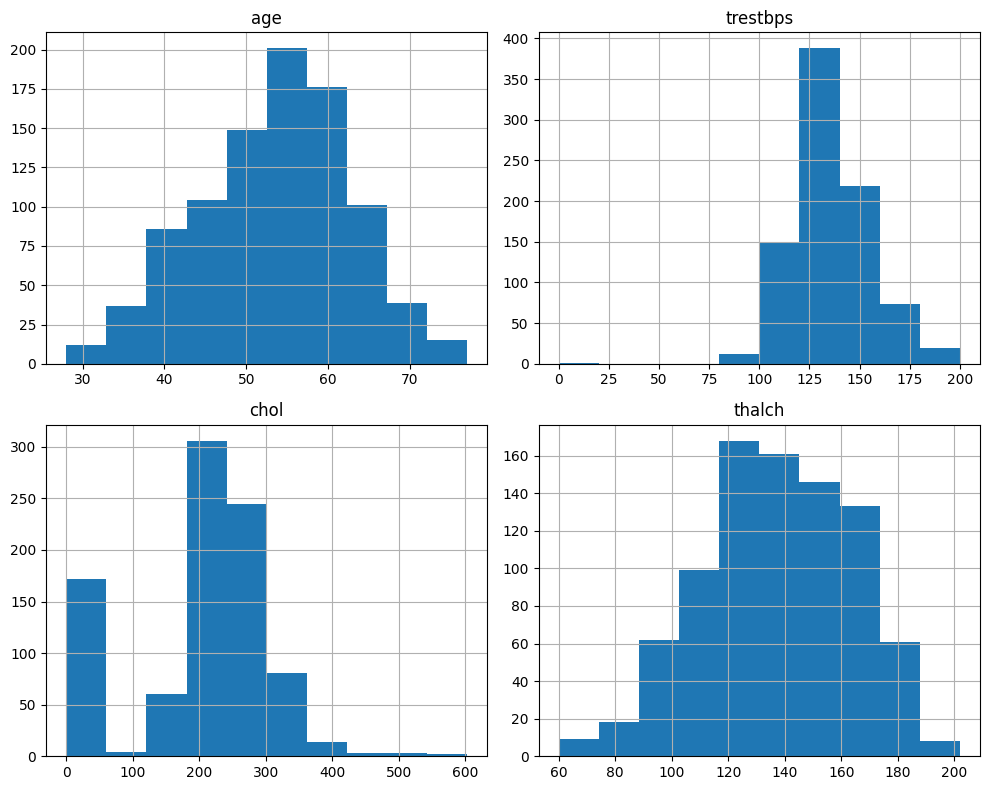

In [29]:
df_heart[['age', 'trestbps', 'chol', 'thalch']].hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

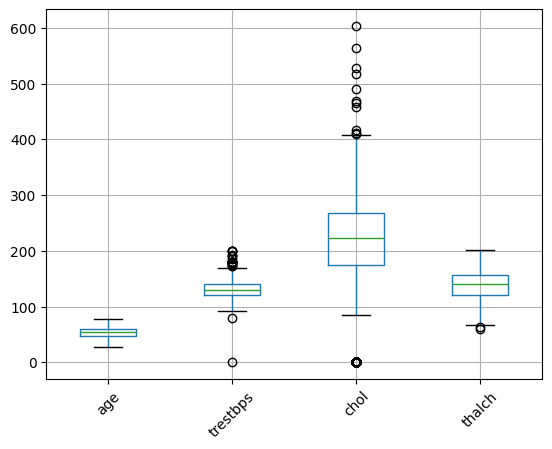

In [30]:
df_heart.boxplot(column=['age', 'trestbps', 'chol', 'thalch'])
plt.xticks(rotation=45)
plt.show()


###Explanations, Results and Reflection
Using the hostogramsoth Age and Thalach (max heart rate) look symmetric.

Cholesterol seems strongly positively skewed with many outliers above 400 and most extreme outliers above 500. Trestbps (resting bp) also seems moderately positively skewed with outliers above 150. Both of these also show 0 values which are not humanly possible.

Skewed data doesnt effect the chosen imputation choice as the median values are not effected by outliers, but mean is.
The 0 values may produce bias so may be dealt with before imputation.

###Step 4 - Handling Missing Values
- Identify columns with missing values and how many
- Decide to keep and impute, or drop the feature
- Fill missing values in columns kept: median for numerical, mode for categorical
- Assign the result back to the column

In [ ]:

df_heart.isnull().sum() / len(df_heart)

columns_to_drop=['thal', 'ca', 'slope', 'id','dataset']

df_heart = df_heart.drop(columns=columns_to_drop)

numerical_columns = ['trestbps','chol','oldpeak', 'thalch']

df_heart[numerical_columns] = df_heart[numerical_columns].fillna(df_heart[numerical_columns].median())


df_heart['exang'] = df_heart['exang'].fillna(df_heart['exang'].mode()[0])
df_heart['fbs'] = df_heart['fbs'].fillna(df_heart['fbs'].mode()[0])
df_heart['restecg'] = df_heart['restecg'].fillna(df_heart['restecg'].mode()[0])



###Explanations, Results and Reflection
The following were dropped:
- thal
 - ca
 - slope
- id
- dataset

I believe a proportion of 50% or greater of missing values must always be dropped and lower than 30% should be imputed.
ca was dropped as almost 70% of its data was missing so imputing could cause higher bias and lower reliability.

More than 50% of thal was missing

slope has 34% missing and wasnt believed to be essential for early detection so was dropped to prevent increased bias.

Neither ID or dataset were meaningful.


The median and mode may be safer than mean when abnormal values exist as they are less influenced by skewed variables and outliers and unrealistic values.

In a clinical context median is a better representation of an average patient due to extreme circumstances.

Imputation is important to preserve datasets and prevent loss. Dropping rows would lose too many entries and dropping columns would lose important information needed for a model to carry out predictions.

 ***from here below the PBL steps have been followed however documentation and reflection is incomplete**
###Step 5 - Handle Abnormal Values

In [32]:
df_heart['age'] = df_heart['age'].clip(lower=0, upper=120)
df_heart['trestbps'] = df_heart['trestbps'].clip(lower=70, upper=200)
df_heart['chol'] = df_heart['chol'].clip(lower=100, upper=400)
df_heart['thalch'] = df_heart['thalch'].clip(lower=70, upper=220)


###Step 6 - Handle Categorical Variables

In [33]:
df_heart = pd.get_dummies(df_heart, columns=['cp','fbs', 'exang','sex'], drop_first=True)
le = LabelEncoder()
df_heart['restecg'] = le.fit_transform(df_heart['restecg'])

###Step 7 - Scale Numerical Features

In [34]:
scaler = StandardScaler()
df_heart[['trestbps', 'chol', 'oldpeak', 'thalch']] = scaler.fit_transform(df_heart[['trestbps', 'chol', 'oldpeak', 'thalch']])

###Step 8 - Save the Cleaned Dataset


In [35]:
df_heart.to_csv('cleaned_heart_disease.csv', index=False)

##Task 2: Feature selection

###Step 1 -  Split the Dataset into Training and Testing Sets

In [36]:
from sklearn.model_selection import train_test_split
X = df_heart.drop('target', axis=1)
y = df_heart['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


###Step 2 -  Explore Feature Importance Using Correlation Analysis

In [37]:
correlation_matrix = X_train.join(y_train).corr()

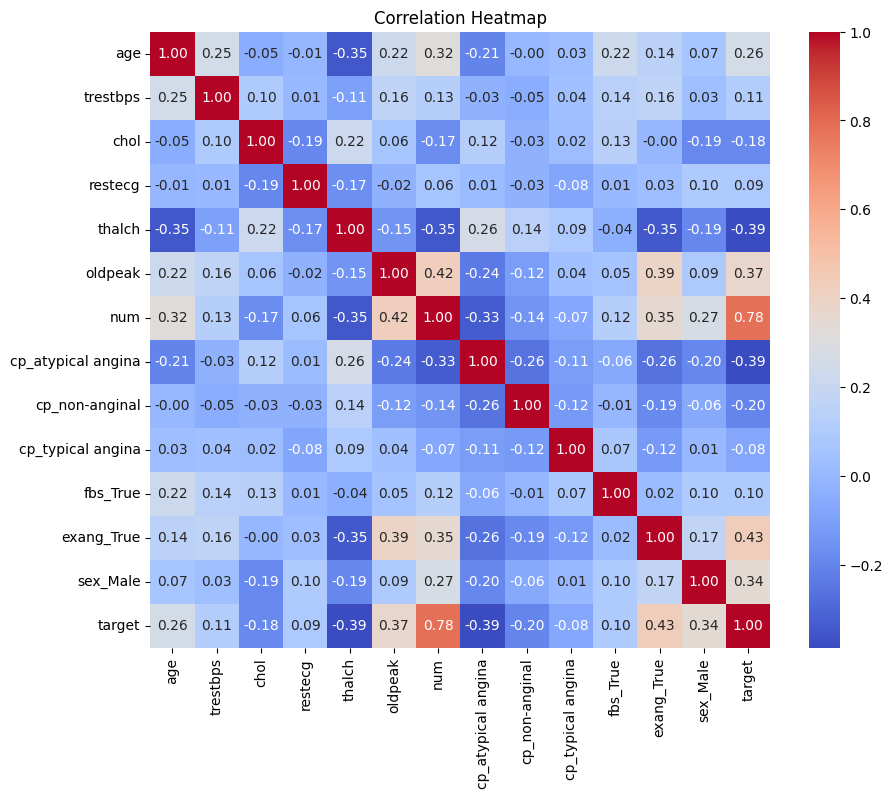

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

### Step 3 -  Select Relevant Features

In [39]:
relevant_features = ['oldpeak','age','exang_True','sex_Male','thalch','cp_atypical angina']
X_train = X_train[relevant_features]
X_test = X_test[relevant_features]

##Task 3: Model Training and Evaluation


###Step 1 - Train Multiple Machine Learning Models

In [40]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [41]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [42]:
from sklearn.svm import SVC
svm_model = SVC(random_state=42, kernel='linear')
svm_model.fit(X_train, y_train)

SVC(kernel='linear', random_state=42)

In [43]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

###Step 2 - Evaluate Models on the Testing Set

In [44]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
y_pred_lr = lr_model.predict(X_test)
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
cm_lr = confusion_matrix(y_test, y_pred_lr)

In [45]:
y_pred_rf = rf_model.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
cm_rf = confusion_matrix(y_test, y_pred_rf)

In [46]:
y_pred_svm = svm_model.predict(X_test)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
cm_svm = confusion_matrix(y_test, y_pred_svm)

In [47]:
y_pred_knn = knn_model.predict(X_test)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
cm_knn = confusion_matrix(y_test, y_pred_knn)

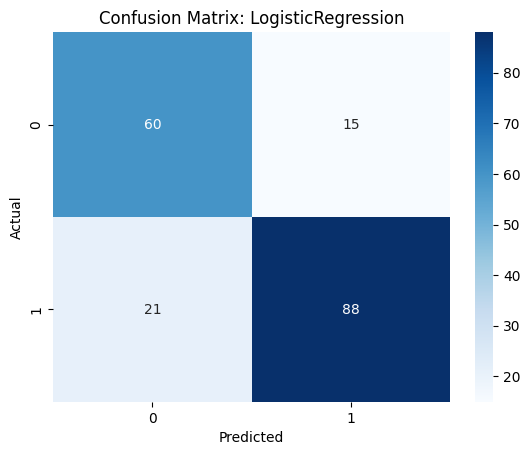

In [48]:
import seaborn as sns
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix: {type(lr_model).__name__}')
plt.show()

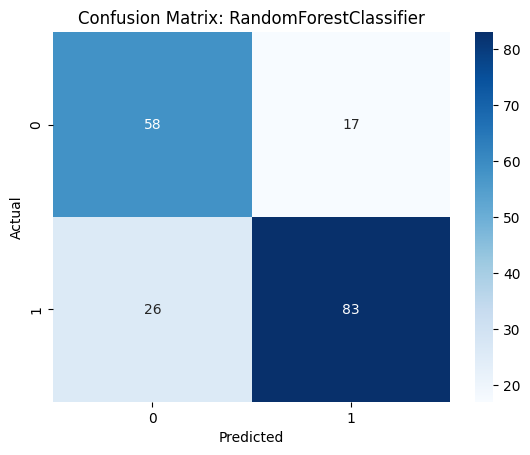

In [49]:
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix: {type(rf_model).__name__}')
plt.show()

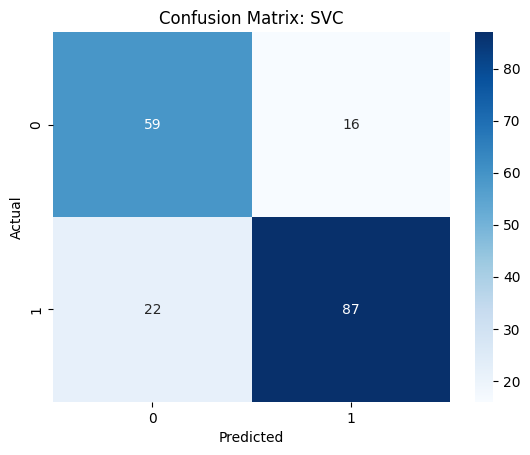

In [50]:

sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix: {type(svm_model).__name__}')
plt.show()

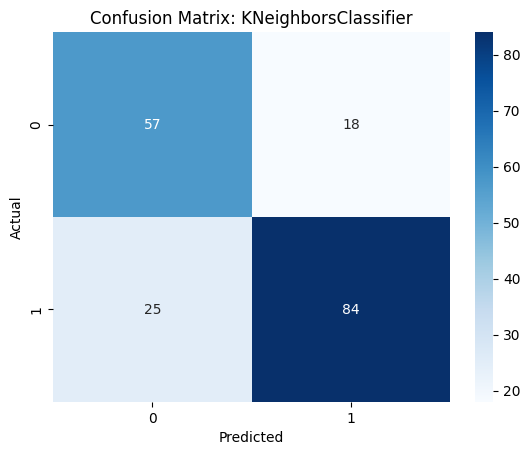

In [51]:

sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix: {type(knn_model).__name__}')
plt.show()

#PBL3: Machine Learning Evaluation and Bias

**a mistake was made in this PBL - I should not have dropped the columns with missing features but rather imputed them because a very small amount of features were null values. Ideally I would fix this before submission but I am realising this after completing this PBL and have learnt from my mistakes but unfortunately do not have the time to redo and reevaluate the models in this PBL so unfortunately my models do not work as well as they should have. I have recognised where I made the wrong decision and have documented it at the end of the PBL reflection but I believe every other part of the PBL is correct - please consider accpeting this PBL as valid.

### Overview
This final section of the notebook explores prediction of recurrence of breast cancer post-treatment using clinical and demographic data. There is a focus on evaulation of metrics and imbalance between classes as well as the effect of bias and data leakage on models.

**Dataset:**

The dataset used is the UCI Breast Cancer Dataset containing anonymised patient records.

Each patient has the following:

- Demographics: age range
- Clinical measurements: tumour size, number of invaded lymph nodes, degree of malignancy
- Categorical features: breast location, breast quadrant, menopause status, node caps, irradiation
- Target: recurrence events or no recurrence events



####Clinical context:
- A missed recurrence is a false negative
- Missing a recurrence can delay care
- False positives can cause unecessary anxiety and procedures.

####Learning objectives addressed:
- Preprocess the breast cancer dataset and train a baseline classifier
- Evaluate models using accuracy, precision, recall, specificity, and ROC-AUC
- Use hyperparameter tuning with different scoring metrics and interpret the impact
- Address class imbalance (e.g. with SMOTE) and compare performance
- Explain data leakage and why preprocessing must follow train-test split
- Interpret results in a clinical context


##Task 1 - Baseline Model and Evaluation Metrics



###Step 1: Loading and Inspecting data

The csv file is loaded into a pandas dataframe and inspected for structure, missing values and target variable distribution using the same functions as previous PBLS such as .head() and .isnull().

In this case the target variable is Class which can have 2 values: recurrence events and non-recurrence events of tumours.

In [52]:
#import library
import pandas as pd

In [53]:
#loading dataset into a dataframe
df_cancer=pd.read_csv('breast_cancer.csv')

#inspecting structure
#first 10 rows
print('First 10 rows:')
print(df_cancer.head(10))

#rows and columns
print('\nSummary:')
print(df_cancer.info())

#inspecting missing values
print('\nMissing values:')
print(df_cancer.isnull().sum())

#8 missing node caps, 1 missing breast quadrant
#interval based features: age, tumour size, invaded nodes

#dealing with missing values and ensuring change
df_cancer = df_cancer.dropna()
print('\nDropping missing values:')
print(df_cancer.isnull().sum())

First 10 rows:
     age menopause tumor-size inv-nodes node-caps  deg-malig breast  \
0  30-39   premeno      30-34       0-2        no          3   left   
1  40-49   premeno      20-24       0-2        no          2  right   
2  40-49   premeno      20-24       0-2        no          2   left   
3  60-69      ge40      15-19       0-2        no          2  right   
4  40-49   premeno        0-4       0-2        no          2  right   
5  60-69      ge40      15-19       0-2        no          2   left   
6  50-59   premeno      25-29       0-2        no          2   left   
7  60-69      ge40      20-24       0-2        no          1   left   
8  40-49   premeno      50-54       0-2        no          2   left   
9  40-49   premeno      20-24       0-2        no          2  right   

  breast-quad irradiat                 Class  
0    left_low       no  no-recurrence-events  
1    right_up       no  no-recurrence-events  
2    left_low       no  no-recurrence-events  
3     left_up  

In [54]:
#inspecting distribution of target variable "Class"
df_cancer['Class'].value_counts()

#196 non recurrnece, 81 recurrence shows class imbalance towards non-recurrence events

,count
Class,
no-recurrence-events,196
recurrence-events,81


###Explanations, Results and Reflection
Originally, 9 rows contained missing values, these were removed as it is a small proportion of the dataset and will not significantly effect the model's performance.

After removing null rows, the dataset contains 277 rows. There are 10 columns which decribe features of tumours or information about the respective patient.

The numerical columns are "age", "tumor-size" and "inv-nodes", while the categorical columns are "menopause", "node-caps", "deg-malig", "breast", "breast-quad", "irradiat" and the target variable "Class".

After inspecting the distribution of the target variable, it is shown that there are 196 "non-recurrance" cases while only 81 "recurrance" cases. This indicated that there is class imbalance towards non-recurrence cases. If used  for a model's training, it would favour predicting "non-recurrence" in patients and may fail at "recurrence" case detection, while still portraying high accuracy.

Recall would give more information about how many cases are correctly detected. It is especially important for recurrance prediction as this is a medical context. If a patient were to be misdiagnosed they would be under the life-threatening impression that they were safe when they actually need treatment.

###Step 2: Converting Interval-Based Features to Numeric

First identified interval based features as age, tumour size, invaded nodes. Created a function to take values at either end of interval and take an average to use as the midpoint value. Now values are numeric.

In [55]:
#age, tumour size, invaded nodes are interval based strings
#converting intervals to numerical midpoint values by finding average
def midpoint(number_range):
  lower,upper = map(int, str(number_range).split('-'))
  return (lower+upper)/2

#apply to feature columns
df_cancer['age'] = df_cancer['age'].apply(midpoint)
df_cancer['tumor-size'] = df_cancer['tumor-size'].apply(midpoint)
df_cancer['inv-nodes'] = df_cancer['inv-nodes'].apply(midpoint)

#checking first few rows after function applied to ensure midpoints used
print(df_cancer[['age','tumor-size','inv-nodes']].head())


    age  tumor-size  inv-nodes
0  34.5        32.0        1.0
1  44.5        22.0        1.0
2  44.5        22.0        1.0
3  64.5        17.0        1.0
4  44.5         2.0        1.0


###Explanations, Results and Reflection



Using the midpoint of the intervals is appropriate for numerical values as the intervals do not provide a single useful exact value. If either of the bounds are selected they cause bias by underestimating or overestimating. The middle value would provide the least biased approximate among uniformly distributed values in the interval.

Since missing values have already been dropped the function doesn't break. If a value is not in interval format we could add a safeguard to prevent error occurrence.

###Step 3: Test-Train Splitting with Stratified Sampling

Features and Target are split using train_test_split with stratify=y by 80/20. Training and testing proportions are checked to ensure similarity.

Stratified sampling used as it allows for class distribution to be preserved among both sets.

In [56]:
from sklearn.model_selection import train_test_split

#create feature matrix from df
#drop label to predict
X = df_cancer.drop(columns=['Class'])

#create target to predict
y = df_cancer['Class']

#split into training and testing sets with 80/20 split, fix random state for reproducibily
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [57]:
#check class distributions
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Class
no-recurrence-events    0.705882
recurrence-events       0.294118
Name: proportion, dtype: float64
Class
no-recurrence-events    0.714286
recurrence-events       0.285714
Name: proportion, dtype: float64


###Explanations, Results and Reflection
Statified sampling is used for this dataset due to class imbalance. If a simple random split was used, the testing set could end up containing a little amount of recurrence cases or the training set could contain even more non-recurrence cases. The model would not be reliable and would evaluate incorrectly.
By using stratified sampling, it is ensured that the proportions of classes in each sets matches the original datasets. This is seen in the printed "value counts" of the original set and the training/testing sets matching.

Encoding and scaling must be applied after the split to prevent data leakage.

If scaling were applied on the original dataset, the test set would influcnce the scaling, but when scaling is fit on training data this doesnt happen, ensuring the data hasnt been seen before.




###Step 4: Encoding Categorical Variables and Scale Numerical Features

One hot encoding used to turn columns in the training set into binary values for model to understand.
Numerical features scaled to allow modle to find optimal solutions.
Encoders and scalers fit only onto training set, then both training and testing set transformed.

In [58]:
from sklearn.preprocessing import StandardScaler

#use one hot encoding to turn categorical columns in training set into numerical
#create binary columns for each feature
X_train = pd.get_dummies(X_train, columns=['menopause', 'node-caps', 'breast', 'breast-quad','irradiat'], drop_first=True)

#ensure test has same columns as train
#if a value is in train and not test, set to 0
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [59]:
#create object for standardising features
scaler = StandardScaler()

#fit onto training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

#apply same tranformation to testing set without fitting (fitting to test = data leakage)
X_test_scaled = scaler.transform(X_test)

In [60]:
# checking for confirmation
print(X_train_scaled.shape)
print(X_test_scaled.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))
print(X_train.dtypes)

(221, 13)
(56, 13)
Class
no-recurrence-events    0.705882
recurrence-events       0.294118
Name: proportion, dtype: float64
Class
no-recurrence-events    0.714286
recurrence-events       0.285714
Name: proportion, dtype: float64
age                      float64
tumor-size               float64
inv-nodes                float64
deg-malig                  int64
menopause_lt40              bool
menopause_premeno           bool
node-caps_yes               bool
breast_right                bool
breast-quad_left_low        bool
breast-quad_left_up         bool
breast-quad_right_low       bool
breast-quad_right_up        bool
irradiat_yes                bool
dtype: object


###Explanations, Results and Reflection

Algorithms that require scaled features are those that rely on gradient optimisation. This includes KNN, SVM and Logistic Regression like used here. For these models, if one feature has a larger magnitude than th others it has a greater influence on the model's optimisation process.

Scaling was applied after splitting the data. If it was done before, the model would have access to the test set data and would learn from this information to appear to perform better than its actual performance on unseen data.

To ensure the testing and training set get the same encoding

`X_test = X_test.reindex(columns=X_train.columns, fill_value=0)` was used.

 It forces the test set to have the same dummy variable columns as the test set and if any missing columns exist in the test set they get added and get a value of 0. This ensures dimensions of both sets are equal.

###Step 5: Training a Baseline Classifier

The logistic regression classifier was chosen and used to train a set.
Predictions on the test set were carried out.

In [61]:
from sklearn.linear_model import LogisticRegression

#create model for classification using LR algorithm
model = LogisticRegression(random_state=42, max_iter=1000)

#train model with sclaed training data and allow model to create relationships between features and labels
model.fit(X_train_scaled, y_train)

#predictions on unseen test data
y_pred = model.predict(X_test_scaled)

This is a baseline model that gives you information on the minimum expected performance for comparisons to more complex models.
It will later be compared to models like decision trees or random forests.

###Step 6: Evaluating with Multiple Metrics

Evaluation metrics are computed on the test set including accuracy, precision, recall, sensitivity and ROC-AUC.

- Accuracy : Proportion of all correct predications among all predications

- Precision : Proportion of correct predictions among all positive predictions

- Recall: Proportion of true positives among all actual
positive cases

- Specificity: Proportion of true negatives among all the actual negative cases

- ROC-AUC: Area under a ROC curve (to understand trade off between recall and specicion), where a larger area indicated good performance.

A confusion matrix is plotted for visualisation using a seaborn heatmap.

In [62]:
#import evalutation metrics
from sklearn.metrics import confusion_matrix, roc_auc_score

#identify true and predicted labels
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# baseline accuracy, precision, recall, specificity from tn, fp, fn, tp
BL_accuracy = (tp + tn) / (tp + tn + fp + fn)
BL_precision = tp / (tp + fp)
BL_recall = tp / (tp + fn)
BL_specificity = tn / (tn + fp)

print("Accuracy:", BL_accuracy)
print("Precision:", BL_precision)
print("Recall:", BL_recall)
print("Specificity:", BL_specificity)

Accuracy: 0.75
Precision: 0.6666666666666666
Recall: 0.25
Specificity: 0.95


Model has high accuracy of 75% but very low recurrence recall of 25%. This suggests the model fails to detect most recurrence cases. High specificity of 95% shows strong performance when identifying non-recurrence cases.

In [63]:
#ROC-AUC score - probability of positives
BL_roc_auc = roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1])


The ROC-AUC value of 0.678 implies that the model can distinguish some recurrence cases.

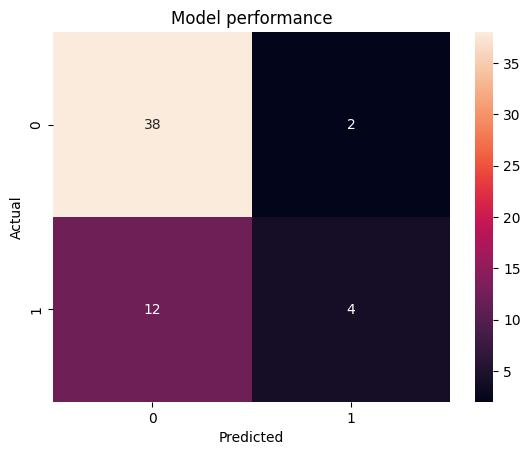

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

#plot and display confusion matrix as heatmap
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Model performance')
plt.show()


###Explanations, Results and Reflection
A false negative is when the model predicts non-recurrence incorrectly when there actually is recurrence in a patient. This means the patient is under the impression they don't require any treatment and are safe.

A false positive is when the model predicts recurrence occurs in a patient, when it does not. This means the patient may undergo unecessary treatment and stress.

In this clinical setting, recall should be prioritised as false negatives (failing to identify recurrences) drastically effect a patient's life and health.

####Task 1 documentation
Initially we had 3 interval based features - age, tumor-size, inv-nodes. These were converted to midpoint values by splitting the interval at the '-' and finding the average of the endpoint bounds. If the lower bound were chosen it would underestimate values and if the upper bound were chosen it would overestimate the value.

Within categorical values, there was nominal data and ordinal data. Nominal data features were encoded using one hot encoding and the ordinal deg-malig feature was kept as numeric. This made sure all features were number based and useful for training.

The data was split 80/20 for training and testing respectively. This was done using stratified sampling due to class imbalance to ensure class proportions remained the same.

After the split, encoding and scaling happened on the training set, then to the test set. This was to prevent data leakage and ensured that the data in the test set remained new to the model to prevent bias.

Logistic regression was used as a baseline model because it is a simple linear classifier that can be used to compare to more complex models. The hyperparameters used were `random_state=42` - ensuring reproducibility and `max_iter=100` - ensuring convergence.

Below is shown the reported accuracy, precision, recall, specificity and ROC-AUC.
- Accuracy: 0.75
- Precision: 0.67
- Recall: 0.25
- Specificity: 0.95
- ROC-AUC: 0.68

The model's accuracy of 75% seems high at first but compared to the baseline class, it is only 4% higher. The low recall of 25% suggests 3 out of every 4 recurrence cases are not identified. In a clinical context this is bad as not spotting recurrence may be life threatening.

High specificity of 95% suggests the model can identify non-recurrence cases with strong accuracy but this also leads to more false negatives.

The ROC-AUC of around 0.678 indicates only moderate ability to discriminate. It suggests that performance may not be strong but some recurrence and non-recurrence cases can be distuished among each other.


##Task 2 - Hyperparameter Tuning and Choice of Scoring Metric


###Step 1: Choosing a Model and Hyperparameters

- In task 1 Linear Regression was used so this will be chosen again and has parameters C and Solver

Hyperparameters are tuned with cross-validation instead of using the test set to ensure no bias by data leakage. If the test set were used for this step, the model would be optimised to the test set.

###Step 2: Tuning Using One Scoring Metric

Used GridSearch to find best hyperparameters for optimisation of model using recall scoring metric on same training data as baseline model using same cv and random state.

In [65]:
from sklearn.linear_model import LogisticRegression

#import GridSearchCV for hyperparameter tuning
from sklearn.model_selection import GridSearchCV

#defining model
LR = LogisticRegression(random_state=42, max_iter=1000)

#defining hyperparameters
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100],'solver': ['liblinear', 'lbfgs']}

#ensuring target is encoded as 0/1
y_train = (y_train == 'recurrence-events').astype(int)
y_test = (y_test == 'recurrence-events').astype(int)

#create grid for recall
grid_recall = GridSearchCV(LR, param_grid, cv=5, scoring='recall')

#run search - train models and use cross validation for evauation
grid_recall.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000, random_state=42),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'solver': ['liblinear', 'lbfgs']},
             scoring='recall')

In [66]:
#print hyperparameters used for grid search that have highest recall
print("Best hyperparameter combination:" , grid_recall.best_params_)

#print best cross validation recall store across the 5 folds
print("Best cross-validation score:" , grid_recall.best_score_)

Best hyperparameter combination: {'C': 0.001, 'solver': 'liblinear'}
Best cross-validation score: 0.5076923076923077


###Explanations, Results and Reflection

The cross validation score is approximatly 0.51. This is the average recall across 5 splits of the training set that shows how well the model should generalise to the test set that is unseen. The test set cannot be used to select hyperparameters because this would influence the model's performance by causing it to be greater due to data leakage.

###Step 3: Tuning Using a Different Scoring Metric

Use GridSearch as in the previous step with a different scoring metric of f1.

In [67]:
#run same grid with different scoring metric : f1
grid_f1 = GridSearchCV(LR, param_grid, cv=5, scoring='f1')
grid_f1.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000, random_state=42),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'solver': ['liblinear', 'lbfgs']},
             scoring='f1')

In [68]:
#best hyperparameter combo and cv score for f1
print("Best hyperparameter combination:", grid_f1.best_params_)
print("Best cross-validation score:", grid_f1.best_score_)

Best hyperparameter combination: {'C': 0.001, 'solver': 'liblinear'}
Best cross-validation score: 0.5218855218855218


###Explanations, Results and Reflection
Recall and F1 tuning both chose the smallest hyperparameter of C=0.001 with solver ='liblinear. The cross validation score of F1 was slightly higher (0.522 compared to 0.508) due to the different ways they both evaluate performance of the model. F1 ranks precision and recall equally wheras recall prefers positive detection. There is a trade off between different metrics. The parameters probably didnt change due to the small size of the dataset and simplicity of the model or just generally small differences in performance.

For recurrence prediction, recall is the most important metric to optimise as a false negative is the worst possible outcome for a patient as it would mean a recurrence could be missed. This would be worse than a false positive as a false positive would have to undergo further tests to rule out actual recurrence and would not put a person in danger.

###Step 4: Retrain and Evaluate on the Test Set

Estimator from recall grid search through `grid.best_estimator` taken
 and used to evaluate models performance on the test set.
 Confusion matrix plotted to explore performance.

In [69]:
#use the LR model with the best hyperparameters for recall
best_model = grid_recall.best_estimator_

#make predictions on the test set
y_pred = best_model.predict(X_test_scaled)

#create confusion matrix and compute evaluation metrics from values
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
specificity = tn / (tn + fp)

roc_auc = roc_auc_score(y_test, best_model.predict_proba(X_test_scaled)[:, 1])

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("Specificity:", specificity)
print("ROC-AUC:", roc_auc)

Accuracy: 0.7142857142857143
Precision: 0.5
Recall: 0.25
Specificity: 0.9
ROC-AUC: 0.6703124999999999


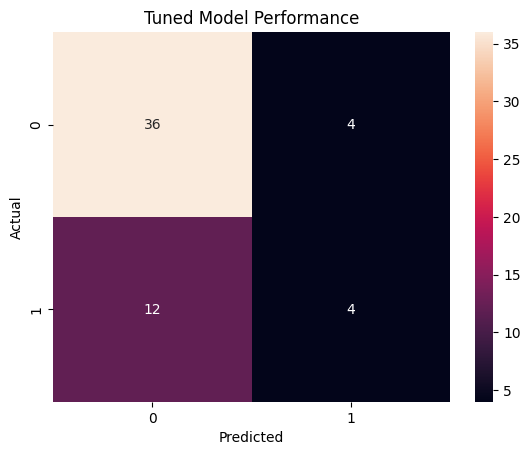

In [70]:
#plot heatmap
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Tuned Model Performance')
plt.show()


###Explanations, Results and Reflection
Compared to the baseline, tuning did not improve any metric. It actually performed worse than the baseline. Accuracy, precision, ROC-AUC and specificity all decreased while recall stayed the same as the baseline. This suggests that recurrence detection does not improve in our model by only adjusting regularisation.

####Task 2 documentation
For the grid search, different regularisation strengths were used and solvers used 5-fold cross validation to examine how hyperparameters effect performance.

The parameter grid used is as shown:
`param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100],'solver': ['liblinear', 'lbfgs']}`

The scoring metrics used for optimisation were recall and F1.

Both recall and F1 optimisation had the same best hyperparameters: 'C': 0.001, 'solver': 'liblinear. This suggests that lower C values (higher regularisation) improve detection of recurrence.

The model performed on the test set as follows:
- Accuracy: 0.714
- Precision: 0.5
- Recall: 0.25
- Specificity: 0.9
- ROC-AUC: 0.678

This shows that tuning did not improve performance on the test set. Recall and ROC-AUC remain at their baseline values while all other metrics decrease. This suggests that tuning regularisation strength is not enough to improve recurrence detection.

Recall should be chosen in this context as failing to detect recurrence cases may be more harmful than maximising accuracy of the model due to a patient's health and life at risk.

##Task 3 - Class Imbalance and SMOTE

###Step 1: Checking Class Distribution

Class distribution in training set found using same data split as previous tasks

In [71]:
#reporting class distibutions in training set
#counts
print(y_train.value_counts())

#proportions of each class
print(y_train.value_counts(normalize=True))
#since 1 has a smaller proportion this is the minority class and we previously encoded this as recurrence

Class
0    156
1     65
Name: count, dtype: int64
Class
0    0.705882
1    0.294118
Name: proportion, dtype: float64


###Explanations, Results and Reflection
This dataset is strongly imbalanced with class 0 (non-recurrence) making up around 70% and class 1 (recurrence) making up 30%. If the model were to optimise accuracy it could predict non-recurrence cases 100% of the time and still get that 70% correct. Accuracy is high due to bias but the model fails to detect recurrence cases.  

SMOTE must be applied to the training set only to ensure data leakage does not occur on the test set. It helps the model learn to identify the minority recurrence cases and help increase recall.

###Step 2: Applying SMOTE to the Training Set
SMOTE (Synthetic Minority Over-sampling Technique) applied to the training set to oversample the minority class (recurrence events) to balance classes.

This is then fit to training featureds and labels to produce resampled data sets.

`pd.Series` then used to check balance of classes after SMOTE

In [72]:
from imblearn.over_sampling import SMOTE
import pandas as pd

#apply SMOTE to training set
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

In [73]:
#convert resample target array into a series to count occurances of classes
print(pd.Series(y_train_resampled).value_counts())
#classes are balanced now

Class
0    156
1    156
Name: count, dtype: int64


###Explanations, Results and Reflection  
SMOTE is the Synthetic Minority Over-sampling Technique algorithm. It balances class distribution by increasing minority class examples randomly by replicating them. This allows recurrence cases to be represented at the same proportion as the non-recurrence cases, in turn causing the model to explore and learn and recognise patterns in the minority class (recurrence) cases, improving recall.

There may be possible drawbacks to SMOTE such as risk of overfitting. This happens when the dataset is small and the model learns very specific patterns and struggles with generalisation to new cases.
Another drawback could possibly be an increase in false postive cases of recurrence. These lower precision.

###Step 3: Training a Model on the Resampled Data

Same LR classifier trained and tested on original testing set

In [74]:
#use same classifier to train on resampled data
model_smote = LogisticRegression(random_state=42, max_iter=1000)
model_smote.fit(X_train_resampled, y_train_resampled)

LogisticRegression(max_iter=1000, random_state=42)

In [75]:
#evaluate on original testing set
y_pred_smote = model_smote.predict(X_test_scaled)
y_prob_smote = model_smote.predict_proba(X_test_scaled)[:, 1]

###Explanations, Results and Reflection
The original test set is used over the resampled test set for evaluation to simulate a real clinical situation, where recurrence cases don't occur 50% of the time like in the SMOTE dataset. Using the resampled test set would not reflect the real world metrics, they would look better than they are. This would make the model unreliable.

###Step 4: Evaluating on the Test Set and Comparing with Baseline
Accuracy, precision, recall, specificity and ROC-AUC computed for SMOTE trained model.

Comparison between previous models carried out.

In [76]:
#create confusion matrix for SMOTE model
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_smote).ravel()

#compute performance metrics
smote_accuracy = (tp + tn) / (tp + tn + fp + fn)
smote_precision = tp / (tp + fp)
smote_recall = tp / (tp + fn)
smote_specificity = tn / (tn + fp)
smote_roc_auc = roc_auc_score(y_test, y_prob_smote)

print("Accuracy:", smote_accuracy)
print("Precision:", smote_precision)
print("Recall:", smote_recall)
print("Specificity:", smote_specificity)
print("ROC-AUC:", smote_roc_auc)

Accuracy: 0.7142857142857143
Precision: 0.5
Recall: 0.375
Specificity: 0.85
ROC-AUC: 0.6656249999999999


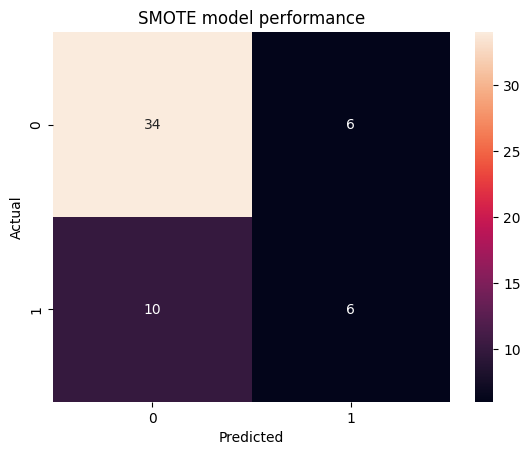

In [77]:
#genrate heatmap
sns.heatmap(confusion_matrix(y_test, y_pred_smote), annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SMOTE model performance")
plt.show()

In [78]:
#print table to visualise differences
comparison= pd.DataFrame({"Model": ["Baseline", "SMOTE"], "Accuracy": [BL_accuracy, smote_accuracy], "Precision": [BL_precision, smote_precision], "Recall": [BL_recall, smote_recall], "Specificity": [BL_specificity, smote_specificity], "ROC-AUC": [BL_roc_auc, smote_roc_auc]
})

print("Comparison of original baseline model and SMOTE model performance: ")
print(comparison)

Comparison of original baseline model and SMOTE model performance: 
      Model  Accuracy  Precision  Recall  Specificity   ROC-AUC
0  Baseline  0.750000   0.666667   0.250         0.95  0.678125
1     SMOTE  0.714286   0.500000   0.375         0.85  0.665625


###Explanations, Results and Reflection
With SMOTE, recall improved from the baseline value of 0.25 to 0.375 - an increase of 12.5%. This means that after fixing class imbalance, the model was able to detect a higher number of recurrence cases.

All other performance metrics decreased slightly with the largest being specificity and precision, decreasing by 10% and 17% respectively.

In a clinical setting, improving recall at the cost of precision is acceptable when the risk of failure of detection of true positive cases outweighs the risk of false positive case detection. In this case, breast cancer is life threatening and chances of survival decrease the longer recurrence of a tumour goes undetected and untreated. An incorrect positive case would be less dangerous than this and would consist of increased stress and further testing before (if any) unecessary treatment but would not put a patients life at risk.

#### Task 3 observations

####Class distribution on training set before and after SMOTE:

Before:
- Class 0 - no recurrence: 156
- Class 1 - recurrence : 65
- 156+65 = 221
- 156/221 = 0.706
- 65/221 = 0.294

70%>30% so class imbalance was present.


After:
- Class 0: 156
- Class 1: 156

Equal 50% split = balanced classes.



####Test set metric comparison

**Metric**	| **Baseline**	| **Tuning** | **SMOTE**

Accuracy:	 0.750 | 0.714 | 0.714

Precision:	 0.667	| 0.500 | 0.500

Recall: 	0.250 | 0.250 | 0.375

Specificity:	 0.950	| 0.90| 0.850

ROC-AUC:	  0.678	| 0.670 | 0.666

SMOTE only helped in increasing recall - where the model detects recurrence cases. It decreased model accuracy, precision, specificity and ROC-AUC. SMOTE decreased the bias towards non-recurrence which increased the number of true positive cases detected but also increased false positive detection. It helped increasing recall of the minority class but did not improve overall performance.  This could be due to the chosen regression model or due to the data not having strongly distinguishable features between the 2 classes.

##Summary and reflection for PBL3
1. Data Quality and Preprocessing

One challenge with the original dataset was the missing values. I removed these completely as there were only 9 values which ends up being a small proportion of the dataset.

Another problem was features being stored as interval strings. These had to be converted to numerical values before they could be used for the models. I solved this by finding the midpoints and using this value rather than either bond to prevent bias.

Preprocessing had to occur before splitting of the data to prevent data leakeage as otherwise there would be influence on the preprocessing parameters.

2. Evaluation Metrics and Clinical Context
Recall is more important than precision when missing positive cases will have a bad consequence, in this case a patient is in danger. A false negative would mean the model failed to detect cancer recurrence (so delayed treatment) which is worse than the further investigation and stress that would be caused from a false positive. Precision would matter more if the investigations due to recurrence were more harmful like biopsies or chemotherapy.

Using different scoring metrics did not change the best model or parameters - the same hyperparameters were decided.

If I were to explain to a clinician I would explain that 0.375 recall of the model means that around 37% of recurence cases can be deteced. Also that the model predicts recurrence correctly 50% of the time. Since many recurrence cases are still missed this model should not be used alone for prediction.

3. Class Imbalance and Bias

In the original set there was class imbalance of around 70/30 (non-rec/rec). The baseline model had high accuracy of around 0.75 but low recall of 0.25. SMOTE was applied to balance the training set to be 50/50. Recall improved by 12.5% from 0.25 to 0.375 but other metrics dropped. The model seems to have lowered its bias towards non-recurrence cases.

The trade offs to resampling are as follows:
- benefits:
Minority class detection improval

- drawbacks:
overfitting risk,
false positive increase

Other sources of bias that effect the model may be data collection bias and size of the dataset.

4. Model Development and Evaluation

The main limitations of my best model were low perfomance metrics including recall. Using logistic regression, linear relationships are assumed.

Assumptions include:
- dropping missing values doesnt cause bias
- logistic regression is correct for our model
- midpoint values are adequate representations of intervals.

To improve the model I would try a random forest model and explore class weighted logistic regression.

5. Learning and Improvement

I found the hyperparameter tuning concepts most difficult. This is because my models seemed to perform worse and worse and probably also to do with the fact that there was little change among my different results. Learning about tradeoffs and carrying out comparisons between performance metrics helped with this.

The biggest mistake I made was dropping columns instead of imputing them and I think this is the reason for my bad model. I have learnt to only drop columns when a large proportion of the specific feature is a null value but here it was a very little amount. Entire features were removed when only few variables were missing and therefore my model will not generalise well. I did learn the important of hyperparameter tuning and SMOTE.
